In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import sys
sys.path.insert(0, '..')
import DAPyr as dap
from DAPyr.DA import lpf_update
from DAPyr.OBS_ERRORS import get_likelihood
from DAPyr.MISC import rkhs_likelihood, diff_map_ext_nystrom
#from ipywidgets import *
import tracemalloc
from importlib import reload
reload(dap)

<module 'DAPyr' from '/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/__init__.py'>

In [18]:
def plot_pab_given_state(x_train, y_train, pab, a, b, c):
    
    ys = np.sort(y_train[0, :])
    ind2 = np.argsort(y_train[0, :])
    diff = np.diff(ys)

    fig, axs = plt.subplots(1,2)

    htp = []

    state_dom = np.arange(33)
    state = a * state_dom * state_dom + b * state_dom + c
    

    dists = np.sum((state-x_train.T)**2, axis=1)
    print(dists.shape)
    ind1 = np.argsort(dists)[0]

    h = pab[ind2, ind1]

    # Normalize for plotting
    normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
    h_norm = h / normalization
    htp.append(h_norm)

    # Plotting
    axs[1].plot(ys, h_norm, linewidth=2)

    axs[1].set_ylim([0, np.max(htp)])


    axs[1].set_xlabel('$y$')
    axs[1].set_ylabel('$p(y | x)$')

    axs[0].plot(state, label='input state')
    axs[0].plot(x_train[:,ind1], label='closest SS match')
    axs[0].set_ylim(-15,20)
    axs[0].legend()
    plt.tight_layout()
    
def plot_pab_given_states(x_train, y_train, pab, states):
    
    ys = np.sort(y_train[0, :])
    ind2 = np.argsort(y_train[0, :])
    diff = np.diff(ys)

    fig, axs = plt.subplots(1,2)

    htp = []
    cmap = plt.get_cmap('tab20')



    for i, state in enumerate(states):

        dists = np.sum((state-x_train.T)**2, axis=1)
        ind1 = np.argsort(dists)[0]
    
        h = pab[ind2, ind1]
    
        # Normalize for plotting
        normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
        h_norm = h / normalization
        htp.append(h_norm)
    
        # Plotting
        axs[1].plot(ys, h_norm, linewidth=2, color=cmap(i))
    
        axs[1].set_ylim([0, np.max(htp)])
        axs[0].plot(state, label='input state', color=cmap(i))
        axs[0].plot(x_train[:,ind1], label='closest SS match', linestyle='dotted', color=cmap(i))


    axs[1].set_xlabel('$y$')
    axs[1].set_ylabel('$p(y | x)$')

    axs[0].set_ylim(-15,20)
    plt.tight_layout()

    
def plot_pab_given_states_size(n, knn, states, closest_by='state'):


    ns = len(states.T)
    smpls_per = 48
    xtn = x_train[:,:smpls_per*n]
    ytn = y_train[:,:smpls_per*n]
    knnn = int(smpls_per*n*knn)

    pab, xm, ym, keeps, C = rkhs_likelihood(ytn.T, xtn.T, 50, knnn, 0, 'knn_adaptive', ns, 1, 0)

    evx, elx, atx, bwx = xm
    evy, ely, aty, bwy = ym

    np.savez(f'pabdata-{n}-knn{knn}-ns{ns}.npz', x_train=xtn, y_train=ytn, pab=pab, evx=evx, evy=evy, elx=elx, ely=ely, bwx=bwx, bwy=bwy, xtn=xtn, ytn=ytn, atx=atx, aty=aty, cov_emb=C)


#   # Load the file
#   data = np.load(f'pabdata-{n}-knn{knn}-ns{ns}.npz')
#   
#   # Bulk unpack into identical variable names
#   pab, evx, evy, elx, ely, bwx, bwy, xtn, ytn, atx, aty = [
#       data[k] for k in ['pab', 'evx', 'evy', 'elx', 'ely', 'bwx', 'bwy', 'xtn', 'ytn', 'atx', 'aty']
#   ]
    
    atx = np.asarray(atx).squeeze()
    aty = np.asarray(aty).squeeze()

    x_emb = (evx * elx).T
    
    ys = np.sort(ytn[0, :])
    ind2 = np.argsort(ytn[0, :])
    diff = np.diff(ys)

    fig, axs = plt.subplots(1,2)

    htp = []
    cmap = plt.get_cmap('tab20')


    for i, state in enumerate(states):

        if closest_by=='state':
            dists = np.sum((state-xtn.T)**2, axis=1)
        elif closest_by=='diff':
            sample = state.reshape(1,-1)
            oose_emb = diff_map_ext_nystrom(sample,
            xtn.T,
            evx,
            elx,
            atx,
            bwx,
            knnn, 
            ns)
            oose_emb *= elx
            dists = np.sum((oose_emb.T - x_emb) ** 2, axis=0)
            
        ind1 = np.argsort(dists)[0]
    
        h = pab[ind2, ind1]
    
        # Normalize for plotting
        normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
        h_norm = h / normalization
        htp.append(h_norm)
    
        # Plotting
        axs[1].plot(ys, h_norm, linewidth=2, color=cmap(i))
    
        axs[1].set_ylim([0, np.max(htp)])
        axs[0].plot(state, label='input state', color=cmap(i))
        if closest_by=='state':
            axs[0].plot(xtn[:,ind1], label='closest SS match', linestyle='dotted', color=cmap(i))
            axs[0].set_title('Input states and closest\n matches in SS')
        elif closest_by=='diff':
            axs[0].plot(xtn[:,ind1], label='closest diff match', linestyle='dotted', color=cmap(i))
            axs[0].set_title('Input states and closest\n matches in DS')


    axs[1].set_title(f'n = {n}, using {closest_by} matches,\n knnf={knn}')
    axs[1].set_xlabel('$y$')
    axs[1].set_ylabel('$p(y | x)$')

    axs[0].set_ylim(-15,20)
    plt.tight_layout()
    fig.savefig(f'fig_n{n}_knn{knn}_ns{ns}_by{closest_by}.png')
    #plt.close()

In [10]:
#data_2k = np.load('2k_lilx.npz')
#data_2k = np.load('2k_midx.npz')
data_2k = np.load('2k_bigx.npz')
print(data_2k.keys())
x_train = data_2k['arr_0']
y_train = data_2k['arr_1']
ns=len(x_train)
print(x_train.shape)
print(y_train.shape)

KeysView(NpzFile '2k_bigx.npz' with keys: arr_0, arr_1)
(49, 48000)
(1, 48000)


In [11]:
#s_dom = np.arange(ns)
#s1 = -0.01 * s_dom ** 2 + 0.46 * s_dom + 4.5
#s2 = -0.23 * s_dom + 3
#s3 = 0.01 * s_dom ** 2 - 0.41 * s_dom - 1.1
#s4 = 0.01 * s_dom ** 2 + 0.2 * s_dom - 5.5
#s5 = -0.02 * s_dom ** 2 + 0.71 * s_dom + 7.5
#states = np.stack((s1,s2,s3,s4,s5))
#len(states.T)

states = np.load('big_training_samps.npz')['arr_0']
rng = np.random.default_rng(1)
inds = rng.choice(states.shape[1], size=5)
states = states[:ns,inds].T

knn is: 960, number of samples = 9600
using median distance without 0s: 0.7311942516236456
knn is: 960, number of samples = 9600
using median distance without 0s: 0.0037908253641838613
knn is: 1920, number of samples = 9600
using median distance without 0s: 0.9542706395245526
knn is: 1920, number of samples = 9600
using median distance without 0s: 0.007639913994664835


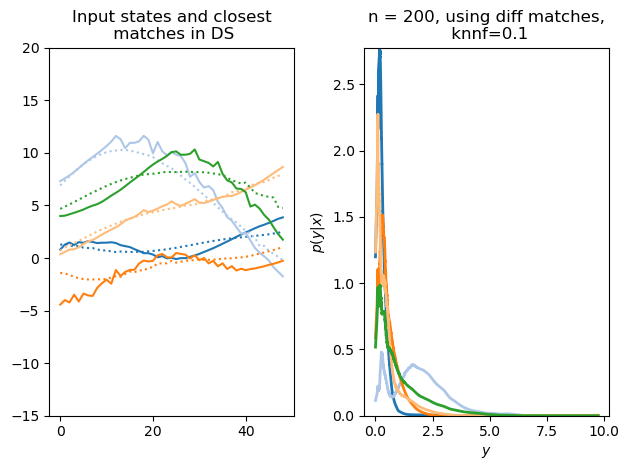

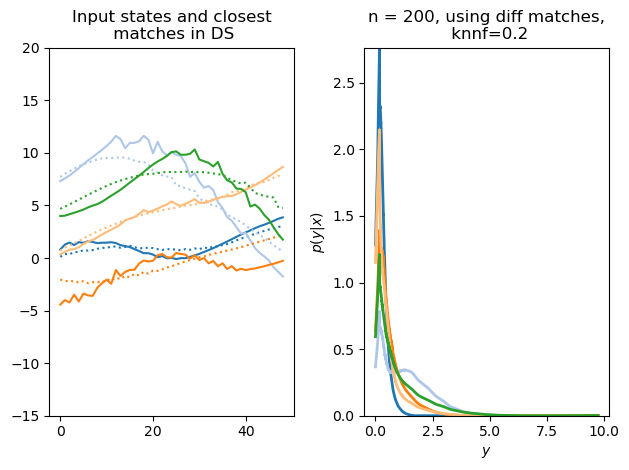

In [20]:
#plot_pab_given_states_size(1000, 0.1, states, closest_by='state')
plot_pab_given_states_size(200, 0.1, states, closest_by='diff')
plot_pab_given_states_size(200, 0.2, states, closest_by='diff')
#plot_pab_given_states_size(1000, 0.2, states, closest_by='diff')
#plot_pab_given_states_size(1000, 0.1, states, closest_by='diff')

In [14]:
mapfile = np.load('pabdata-1000-knn0.2-ns49.npz')

In [17]:
mapfile['cov_emb'].shape

(51, 51)